# Tarea 2 Cristobal Vergara Jofré


P1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import linearmodels.panel as lmp


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

df = pd.read_csv("../../../data/dataset_prueba.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["NAME", "date"]).reset_index(drop=True)
df["log_daily_cases"] = np.log1p(df["daily_cases"])

print("Base cargada correctamente")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
print(f"Periodo: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"Paises: {sorted(df['country'].unique())}")

df.head()

Base cargada correctamente
Filas: 12,040
Columnas: 42
Periodo: 2020-02-17 a 2022-10-17
Paises: ['DE', 'ES', 'FR', 'IT', 'SE']


,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,Valor_Stringency_Index,Valor_GovernmentResponseIndex,Valor_EconomicSupportIndex,Valor_Containment_Health_index,workplace_closing,daily_cases,d2,d1,d3,d4,d5,d6,week,year,CODE,NAME,Population,agriculture,industry,construction,edu2,edu3,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country,log_daily_cases
0,ES-C,2020-02-17,-2.000,4.000,28.000,11.000,5.000,-1.000,-2.151,-4.734,11.110,14.580,0.000,16.670,0.000,0.002,0,0,0,0,0,0,1,2020,ES025C,A Coruña,247.604,0.006,0.042,0.053,0.303,0.660,0.679,0.270,0.409,115.728,16.000,0.161,0.169,5.000,ES,0.002
1,ES-C,2020-02-24,2.600,3.000,31.600,7.600,-1.600,-1.200,-6.335,-6.235,11.110,13.956,0.000,15.956,0.000,0.002,0,0,0,0,0,0,2,2020,ES025C,A Coruña,247.604,0.006,0.042,0.053,0.303,0.660,0.679,0.270,0.409,115.728,16.000,0.161,0.169,5.000,ES,0.002
2,ES-C,2020-03-02,-5.800,-5.600,14.600,3.200,-12.200,2.400,-14.950,-8.989,11.110,11.460,0.000,13.100,0.000,0.037,0,0,0,0,0,0,3,2020,ES025C,A Coruña,247.604,0.006,0.042,0.053,0.303,0.660,0.679,0.270,0.409,115.728,16.000,0.161,0.169,5.000,ES,0.037
3,ES-C,2020-03-09,-3.200,1.400,4.800,5.600,3.000,-0.200,-23.564,-14.919,13.888,13.022,0.000,14.884,0.200,0.424,0,0,0,0,0,0,4,2020,ES025C,A Coruña,247.604,0.006,0.042,0.053,0.303,0.660,0.679,0.270,0.409,115.728,16.000,0.161,0.169,5.000,ES,0.353
4,ES-C,2020-03-16,-27.200,9.800,-8.600,-22.200,-11.600,6.000,-32.178,-26.435,50.460,33.594,0.000,38.396,1.200,4.285,0,0,0,0,0,0,5,2020,ES025C,A Coruña,247.604,0.006,0.042,0.053,0.303,0.660,0.679,0.270,0.409,115.728,16.000,0.161,0.169,5.000,ES,1.665


In [3]:
panel_resumen = pd.DataFrame(
    {
        "n_ciudades": [df["NAME"].nunique()],
        "n_paises": [df["country"].nunique()],
        "n_fechas": [df["date"].nunique()],
        "obs_min_por_ciudad": [df.groupby("NAME").size().min()],
        "obs_max_por_ciudad": [df.groupby("NAME").size().max()],
        "duplicados_ciudad_fecha": [df.duplicated(["iso_code", "NAME", "date"]).sum()],
    }
)

nulos = pd.DataFrame(
    {
        "n_missing": df.isna().sum(),
        "pct_missing": df.isna().mean() * 100,
        "tipo": df.dtypes.astype(str),
    }
).sort_values("pct_missing", ascending=False)

print("Resumen del panel")
display(panel_resumen.T)

print("Faltantes en edu2/edu3")
display(nulos[nulos["n_missing"] > 0])

print("Nulos de edu2/edu3 por pais (%)")
display(
    df.assign(
        edu2_missing=df["edu2"].isna(),
        edu3_missing=df["edu3"].isna(),
    )
    .groupby("country")[["edu2_missing", "edu3_missing"]]
    .mean()
    .mul(100)
)




Resumen del panel


,0
n_ciudades,86
n_paises,5
n_fechas,140
obs_min_por_ciudad,140
obs_max_por_ciudad,140
duplicados_ciudad_fecha,0


Faltantes en edu2/edu3


,n_missing,pct_missing,tipo
edu3,5460,45.349,float64
edu2,5460,45.349,float64


Nulos de edu2/edu3 por pais (%)


,edu2_missing,edu3_missing
country,,
DE,100.000,100.000
ES,0.000,0.000
FR,0.000,0.000
IT,0.000,0.000
SE,0.000,0.000


In [4]:
vars_principales = [
    "workplaces",
    "Valor_Stringency_Index",
    "workplace_closing",
    "daily_cases",
    "log_daily_cases",
    "Population",
    "age_dependency",
    "old_age_dependency",
    "young_age_dependency",
    "sex_ratio",
    "unemp",
    "foreigners",
]

descriptivas = df[vars_principales].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

display(descriptivas)



,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
workplaces,12040.000,-18.667,11.801,-76.787,-60.895,-40.010,-24.358,-16.820,-10.884,-3.617,3.502,19.058
Valor_Stringency_Index,12040.000,27.486,29.836,0.000,0.000,0.000,0.000,15.858,53.420,78.700,87.960,93.520
workplace_closing,12040.000,0.851,0.997,0.000,0.000,0.000,0.000,0.000,2.000,3.000,3.000,3.000
daily_cases,12040.000,2355.733,3154.914,0.000,0.000,0.000,0.037,632.010,3815.644,8209.678,13278.395,22203.314
log_daily_cases,12040.000,5.348,3.477,0.000,0.000,0.000,0.037,6.450,8.247,9.013,9.494,10.008
Population,12040.000,745.474,1277.342,201.048,201.491,207.415,246.794,346.791,620.523,2855.958,10274.884,10274.884
age_dependency,12040.000,0.654,0.073,0.520,0.520,0.541,0.609,0.651,0.682,0.787,0.837,0.837
old_age_dependency,12040.000,0.321,0.053,0.255,0.255,0.265,0.280,0.307,0.338,0.429,0.485,0.485
young_age_dependency,12040.000,0.334,0.063,0.238,0.238,0.247,0.282,0.331,0.366,0.445,0.507,0.507
sex_ratio,12040.000,106.714,4.247,91.449,91.502,100.760,103.523,107.013,109.532,113.676,115.753,115.753


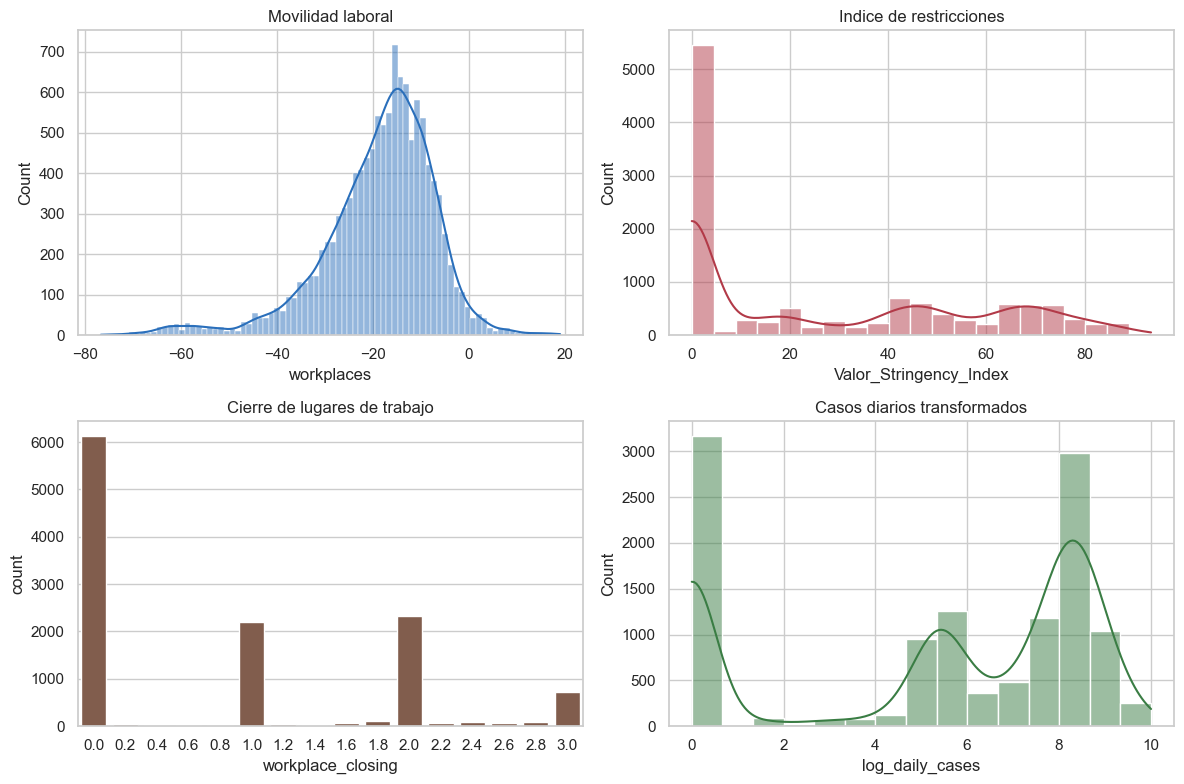

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

sns.histplot(df["workplaces"], kde=True, ax=axes[0], color="#2a6fbb")
axes[0].set_title("Movilidad laboral")
axes[0].set_xlabel("workplaces")

sns.histplot(df["Valor_Stringency_Index"], kde=True, ax=axes[1], color="#b23a48")
axes[1].set_title("Indice de restricciones")
axes[1].set_xlabel("Valor_Stringency_Index")

sns.countplot(x="workplace_closing", data=df, ax=axes[2], color="#8a5a44")
axes[2].set_title("Cierre de lugares de trabajo")
axes[2].set_xlabel("workplace_closing")

sns.histplot(df["log_daily_cases"], kde=True, ax=axes[3], color="#3a7d44")
axes[3].set_title("Casos diarios transformados")
axes[3].set_xlabel("log_daily_cases")

plt.tight_layout()
plt.show()

Resultado, restricciones y situacion sanitaria


,n_ciudades,n_obs,workplaces_prom,stringency_prom,workplace_closing_prom,log_daily_cases_prom
country,,,,,,
DE,39,5460,-16.031,0.000,0.000,5.271
ES,16,2240,-20.045,49.715,1.421,5.432
FR,15,2100,-21.502,46.206,1.529,5.559
IT,14,1960,-20.720,56.786,1.863,5.400
SE,2,280,-23.430,40.145,0.710,4.241


Estructura economica


,Population,agriculture,industry,construction
country,,,,
DE,536.652,0.002,0.120,0.039
ES,698.553,0.015,0.082,0.064
FR,1089.753,0.005,0.106,0.063
IT,969.914,0.013,0.158,0.070
SE,1039.700,0.002,0.056,0.060


Demografia y mercado laboral


,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,foreigners
country,,,,,,
DE,0.616,0.292,0.328,103.815,5.769,8.769
ES,0.628,0.316,0.312,107.949,23.250,7.085
FR,0.739,0.418,0.322,111.125,16.398,7.800
IT,0.702,0.296,0.406,109.400,13.357,8.083
SE,0.623,0.376,0.246,101.509,10.500,7.500


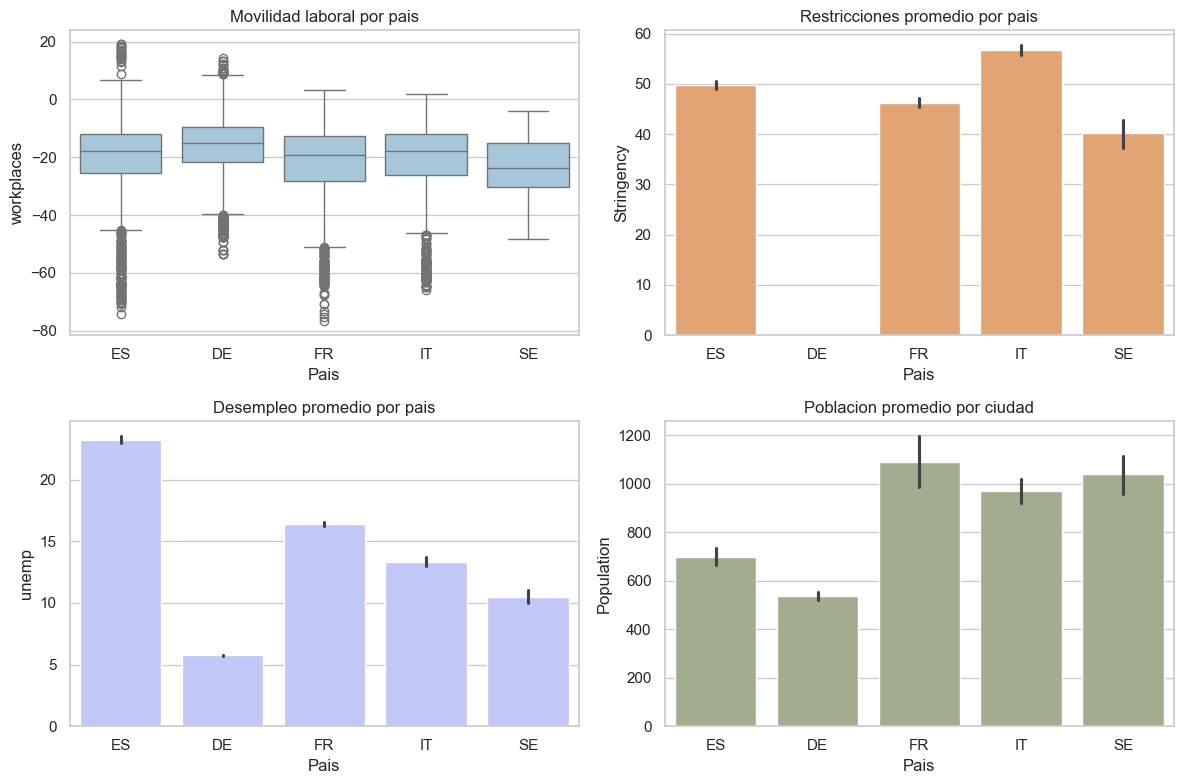

In [6]:
resumen_pais_base = (
    df.groupby("country")
    .agg(
        n_ciudades=("NAME", "nunique"),
        n_obs=("NAME", "size"),
        workplaces_prom=("workplaces", "mean"),
        stringency_prom=("Valor_Stringency_Index", "mean"),
        workplace_closing_prom=("workplace_closing", "mean"),
        log_daily_cases_prom=("log_daily_cases", "mean"),
    )
    .round(3)
)

resumen_pais_economico = (
    df.groupby("country")[
        ["Population", "agriculture", "industry", "construction"]
    ]
    .mean()
    .round(3)
)

resumen_pais_demografico = (
    df.groupby("country")[
        [
            "age_dependency",
            "old_age_dependency",
            "young_age_dependency",
            "sex_ratio",
            "unemp",
            "foreigners",
        ]
    ]
    .mean()
    .round(3)
)

print("Resultado, restricciones y situacion sanitaria")
display(resumen_pais_base)

print("Estructura economica")
display(resumen_pais_economico)

print("Demografia y mercado laboral")
display(resumen_pais_demografico)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

sns.boxplot(data=df, x="country", y="workplaces", ax=axes[0], color="#9ecae1")
axes[0].set_title("Movilidad laboral por pais")
axes[0].set_xlabel("Pais")
axes[0].set_ylabel("workplaces")

sns.barplot(data=df, x="country", y="Valor_Stringency_Index", ax=axes[1], color="#f4a261")
axes[1].set_title("Restricciones promedio por pais")
axes[1].set_xlabel("Pais")
axes[1].set_ylabel("Stringency")

sns.barplot(data=df, x="country", y="unemp", ax=axes[2], color="#b8c0ff")
axes[2].set_title("Desempleo promedio por pais")
axes[2].set_xlabel("Pais")
axes[2].set_ylabel("unemp")

sns.barplot(data=df, x="country", y="Population", ax=axes[3], color="#a3b18a")
axes[3].set_title("Poblacion promedio por ciudad")
axes[3].set_xlabel("Pais")
axes[3].set_ylabel("Population")

plt.tight_layout()
plt.show()


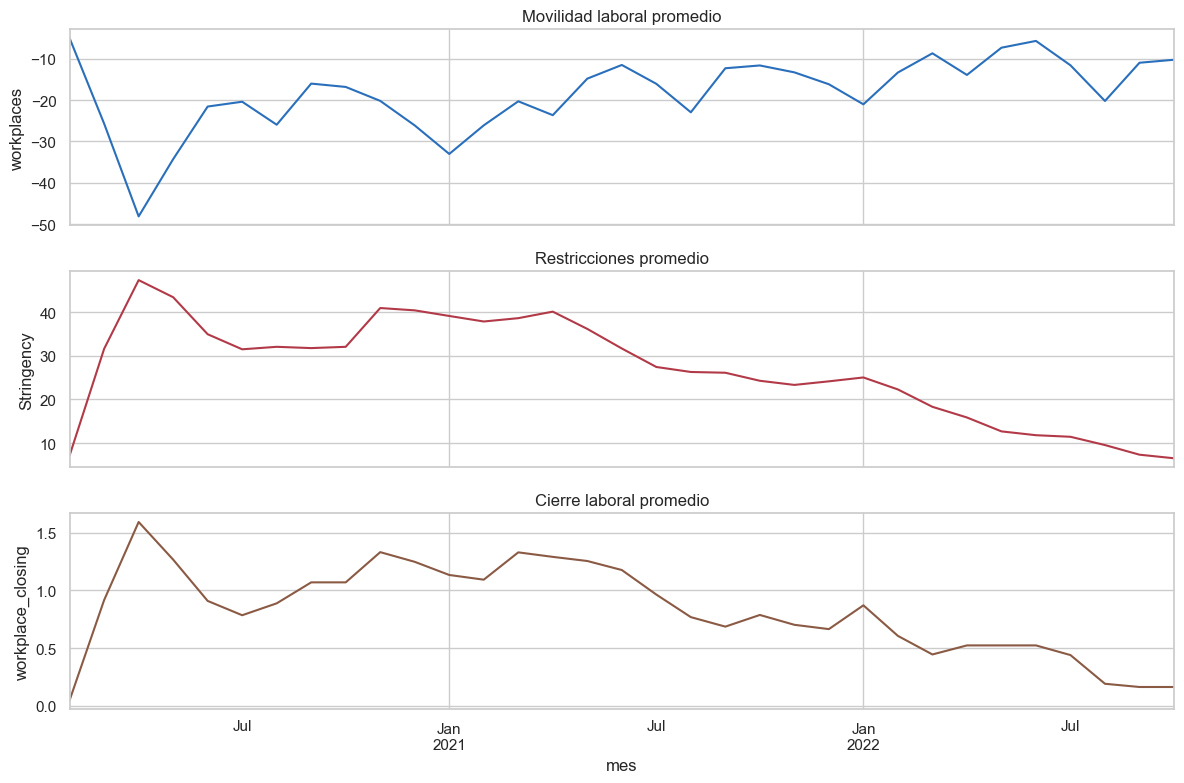

In [7]:
mensual = (
    df.assign(mes=df["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes")[["workplaces", "Valor_Stringency_Index", "workplace_closing"]]
    .mean()
)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

mensual["workplaces"].plot(ax=axes[0], color="#2a6fbb")
axes[0].set_title("Movilidad laboral promedio")
axes[0].set_ylabel("workplaces")

mensual["Valor_Stringency_Index"].plot(ax=axes[1], color="#b23a48")
axes[1].set_title("Restricciones promedio")
axes[1].set_ylabel("Stringency")

mensual["workplace_closing"].plot(ax=axes[2], color="#8a5a44")
axes[2].set_title("Cierre laboral promedio")
axes[2].set_ylabel("workplace_closing")

plt.tight_layout()
plt.show()


Correlaciones principales con workplaces


,corr_con_workplaces
workplaces_raw,0.867
residential_percent_change_from_baseline,-0.804
trend,0.794
transit_stations_percent_change_from_baseline,0.708
retail_and_recreation_percent_change_from_baseline,0.707
grocery_and_pharmacy_percent_change_from_baseline,0.659
week,0.459
Valor_Stringency_Index,-0.413
year,0.396
workplace_closing,-0.388


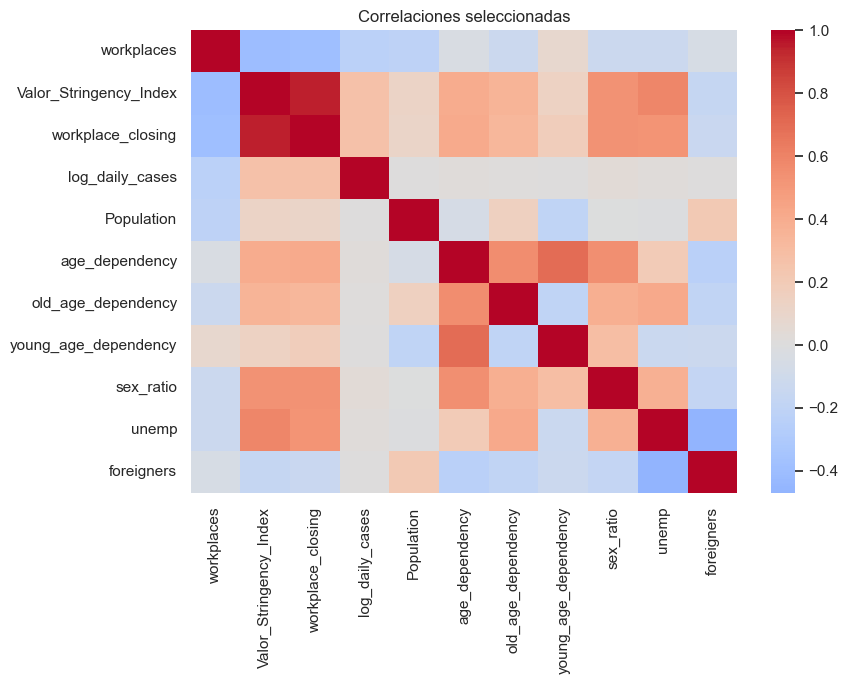

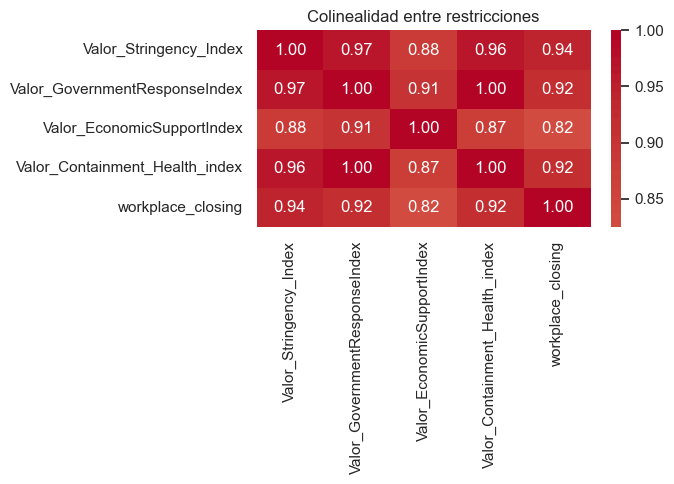

In [8]:
politicas = [
    "Valor_Stringency_Index",
    "Valor_GovernmentResponseIndex",
    "Valor_EconomicSupportIndex",
    "Valor_Containment_Health_index",
    "workplace_closing",
]

controles = [
    "workplaces",
    "Valor_Stringency_Index",
    "workplace_closing",
    "log_daily_cases",
    "Population",
    "age_dependency",
    "old_age_dependency",
    "young_age_dependency",
    "sex_ratio",
    "unemp",
    "foreigners",
]

corr_workplaces = (
    df.select_dtypes(include="number")
    .corr()["workplaces"]
    .drop("workplaces")
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame("corr_con_workplaces")
)

print("Correlaciones principales con workplaces")
display(corr_workplaces.head(15))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[controles].corr(), cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlaciones seleccionadas")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[politicas].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Colinealidad entre restricciones")

plt.tight_layout()
plt.show()



Promedio de d1-d6 por pais


,d1,d2,d3,d4,d5,d6
country,,,,,,
DE,0.000,0.000,0.000,0.000,0.000,0.000
ES,0.507,0.436,0.000,0.507,0.000,0.436
FR,0.000,0.000,0.000,0.000,0.000,0.000
IT,0.000,0.000,0.000,0.000,0.000,0.000
SE,0.529,0.486,0.529,0.000,0.486,0.000


Conteo de observaciones activas


,d1,d2,d3,d4,d5,d6
country,,,,,,
DE,0,0,0,0,0,0
ES,1136,976,0,1136,0,976
FR,0,0,0,0,0,0
IT,0,0,0,0,0,0
SE,148,136,148,0,136,0


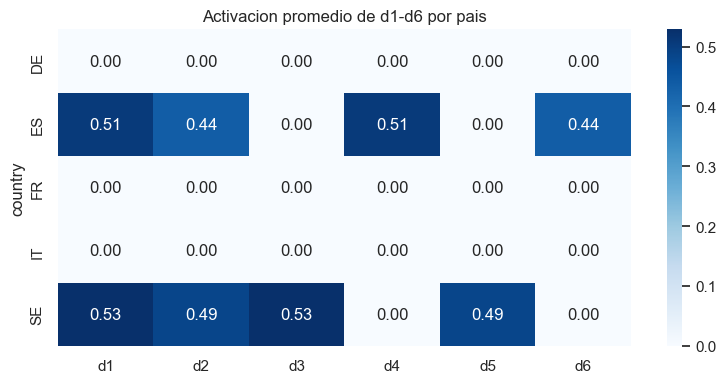

In [9]:
queries = ["d1", "d2", "d3", "d4", "d5", "d6"]

query_promedios = df.groupby("country")[queries].mean()
query_conteos = df.groupby("country")[queries].sum().astype(int)

print("Promedio de d1-d6 por pais")
display(query_promedios)

print("Conteo de observaciones activas")
display(query_conteos)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(query_promedios, cmap="Blues", annot=True, fmt=".2f", ax=ax)
ax.set_title("Activacion promedio de d1-d6 por pais")
plt.tight_layout()
plt.show()


In [10]:
columnas_excluir = ["edu2", "edu3", "d1", "d2", "d3", "d4", "d5", "d6"]
df_modelo = df[df["country"] != "DE"].drop(columns=columnas_excluir).copy()

modelo_base = [
    "Valor_Stringency_Index",
    "log_daily_cases",
    "Population",
    "age_dependency",
    "old_age_dependency",
    "young_age_dependency",
    "sex_ratio",
    "unemp",
    "foreigners",
]

modelo_robustez = [
    "workplace_closing",
    "log_daily_cases",
    "Population",
    "age_dependency",
    "old_age_dependency",
    "young_age_dependency",
    "sex_ratio",
    "unemp",
    "foreigners",
]

print("Columnas excluidas:")
print(columnas_excluir)

print(f"\nDimensiones df original: {df.shape}")
print(f"Dimensiones df_modelo: {df_modelo.shape}")
print("Filtro aplicado en df_modelo: country != 'DE'")



Columnas excluidas:
['edu2', 'edu3', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']

Dimensiones df original: (12040, 42)
Dimensiones df_modelo: (6580, 34)
Filtro aplicado en df_modelo: country != 'DE'


Descriptivas de estructura productiva


,count,mean,std,min,25%,50%,75%,max
agriculture,6580.000,0.011,0.012,0.001,0.004,0.009,0.013,0.071
industry,6580.000,0.111,0.048,0.037,0.070,0.104,0.153,0.233
construction,6580.000,0.066,0.013,0.038,0.056,0.066,0.075,0.153


Promedio de sectores por país


,agriculture,industry,construction
country,,,
ES,0.015,0.082,0.064
FR,0.005,0.106,0.063
IT,0.013,0.158,0.070
SE,0.002,0.056,0.060


Correlación simple con workplaces


agriculture     0.028
industry       -0.001
construction    0.113
Name: workplaces, dtype: float64

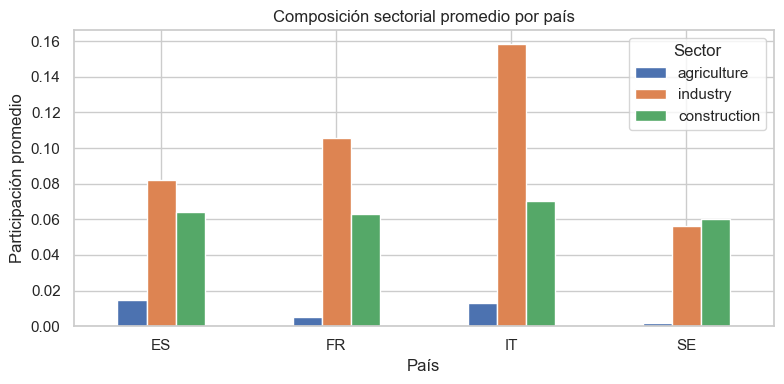

In [11]:
sectores = ["agriculture", "industry", "construction"]

print("Descriptivas de estructura productiva")
display(df_modelo[sectores].describe().T.round(3))

print("Promedio de sectores por país")
display(df_modelo.groupby("country")[sectores].mean().round(3))

print("Correlación simple con workplaces")
display(df_modelo[sectores + ["workplaces"]].corr()["workplaces"].drop("workplaces").round(3))

sectores_pais = df_modelo.groupby("country")[sectores].mean()

sectores_pais.plot(kind="bar", figsize=(8, 4))
plt.title("Composición sectorial promedio por país")
plt.ylabel("Participación promedio")
plt.xlabel("País")
plt.xticks(rotation=0)
plt.legend(title="Sector")
plt.tight_layout()
plt.show()

R P1: Primero se revisó en general el dataset, se observarón cantidad de paises y ciudades, variables de estudio y posibles duplicados. 

Luego se hizo un analisis de valores nulos y se encontró que las columnas edu2 y edu3 contenian la mayoria de nulos ademas de que se concentraban en Alemania por lo que se decidió no usar esas variables. 
Despues al hacer una caracterizacion por pais se encontró que en Alemania no se contaba con la variable de stringency_index (0 para todas las observaciones) lo que no refleja la realidad que vivió Alemania por lo que se decidió no usar ciudades alemanas para los modelos. 

Seguidamente se revisó las distribuciones de algunas variables principales y se encontró que daily cases tenia una distribución muy asimetrica, en especifico muchos valores bajos y 0, por eso se decidió normalizarla y crear log_daily_cases = log(1 + daily_cases) y se usará como variable de control.

Ademas se hicieron graficos de linea para observar cambios temporales de algunas variables como workplaces, stringency y workplace_closing para observar si existia alguna correlacion en simple y se respaldó esta hipotesis ya que se observa a simple vista que aumentos en restricciones coinciden con bajas en movilidad.

Finalmente se analizaron correlaciones y el caso de las variables d1 a d6, en el caso de las correlaciones se encontró que variables de politicas publicas se correlacionan mucho entre si por lo que se decide usar solo una de ellas, en especifico valor_stringency_index. En el caso de las variables d1 a d6, aparte de no estar documentadas, se concentran en solo algunos paises asi que se decide excluirlas. 

Por lo que, en resumen, para seguir el estudio y construir los modelos se excluye Alemania, edu2, edu3, d1, d2, .... y d6.


P2. Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [12]:
df_pooled = df_modelo.copy()

if "NAME" not in df_pooled.columns or "date" not in df_pooled.columns:
    df_pooled = df_pooled.reset_index()


df_pooled["log_population"] = np.log(df_pooled["Population"])

X_base = df_pooled[
    [
        "Valor_Stringency_Index",
        "log_daily_cases",
        "log_population",
        "agriculture",
        "industry",
        "construction",
        "age_dependency",
        "unemp"
    ]
]

year_dummies = pd.get_dummies(df_pooled["year"], prefix="year", drop_first=True, dtype=float)


X = pd.concat([X_base, year_dummies], axis=1)
X = sm.add_constant(X)

y = df_pooled["workplaces"]

df_pooled = df_pooled.set_index(["NAME", "date"])
X.index = df_pooled.index
y.index = df_pooled.index

model = lmp.PanelOLS(y, X)
mco = model.fit(cov_type="robust")

print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.4334
Estimator:                   PanelOLS   R-squared (Between):              0.4065
No. Observations:                6580   R-squared (Within):               0.4359
Date:                Mon, May 25 2026   R-squared (Overall):              0.4334
Time:                        23:36:54   Log-likelihood                -2.429e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      502.47
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(10,6569)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             334.30
                            

R P2: Para iniciar el estudio y estimar la relacion de restricciones del gobierno con la movilidad laboral se hace un modelo pooled OLS, que agrupa todas las observaciones ciudad-semana y estima una relación promedio usando tanto diferencias entre ciudades como variación en el tiempo. La tesis principal es que un aumento en valor_stringency_index se asocia con una baja en workplaces ya que estas restricciones involucran cierres, limites de aforo, teletrabajo, etc. Además se tomó en cuenta que la movilidad laboral puede variar segun situacion de casos covid, poblacion de la ciudad y la composicion por sector mediante las variables agriculture, industry y construction ya que sectores mas presenciales pueden tener patrones distintos de movilidad. Ademas como control demografico se agrega age_dependency y unemp como indicador del mercado laboral. Finalmente se agregan dummies de años para capturar las diferentes etapas de la pandemia.

- `Valor_Stringency_Index` | -0.4186 | p = 0.0000 | significativa
- `log_daily_cases` | 0.8004 | p = 0.0000 | significativa
- `log_population` | -2.8451 | p = 0.0000 | significativa
- `agriculture` | 45.5550 | p = 0.0001 | significativa
- `industry` | 20.1660 | p = 0.0000 | significativa
- `construction` | 132.9700 | p = 0.0000 | significativa
- `age_dependency` | -22.4480 | p = 0.0000 | significativa
- `unemp` | -0.1654 | p = 0.0000 | significativa
- `year_2021` | 3.4142 | p = 0.0000 | significativa
- `year_2022` | 0.9354 | p = 0.0108 | significativa

En el modelo podemos observar que Valor_Stringency_index tiene un coeficiente negativo y significativo, validando la tesis inicial. En magnitud, un aumento de 10 puntos en el índice de restricciones se relaciona con una baja aproximada de 4.2 puntos porcentuales en workplaces. La variable de log_daily_cases aparece positiva y significativa aunque puede estar relacionada a dinamicas de reapertura, adaptacion social o cambios temporales por pandemia mas que por contagios. Ademas se observa que todas las demas variables resultaron significativas, viendo solo los coeficientes el modelo nos dice que las ciudades mas grandes tienen menor movilidad y mayor peso de sectores como industria y construccion tienen mayor movilidad laboral. En el lado demografico mayor desempleo y dependencia etaria se relacionan con menor movilidad. Finalmente las dummies de año muestran que respecto a 2020 la movilidad fue mayor en 2021 y 2022 reflejando una recuperación parcial de la actividad presencial a medida que avanzó la pandemia.

3. Ejecute un modelo efectos fijos para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [13]:
df_fe = df_modelo.copy()

if "NAME" not in df_fe.columns or "date" not in df_fe.columns:
    df_fe = df_fe.reset_index()

df_fe["log_population"] = np.log(df_fe["Population"])

X_base = df_fe[
    [
        "Valor_Stringency_Index",
        "log_daily_cases",
        "log_population",
        "agriculture",
        "industry",
        "construction",
        "age_dependency",
        "unemp"
    ]
]

year_dummies = pd.get_dummies(df_fe["year"], prefix="year", drop_first=True, dtype=float)

X = pd.concat([X_base, year_dummies], axis=1)
X = sm.add_constant(X)

y = df_fe["workplaces"]

df_fe = df_fe.set_index(["NAME", "date"])
X.index = df_fe.index
y.index = df_fe.index

model = lmp.PanelOLS(
    y,
    X,
    entity_effects=True,
    drop_absorbed=True
)

fe = model.fit(cov_type="robust")

print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.4371
Estimator:                   PanelOLS   R-squared (Between):             -15.696
No. Observations:                6580   R-squared (Within):               0.4371
Date:                Mon, May 25 2026   R-squared (Overall):             -0.9486
Time:                        23:36:54   Log-likelihood                -2.397e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      633.34
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                  F(8,6525)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             525.38
                            

C:\Users\crist\AppData\Local\Temp\ipykernel_13864\24459788.py:39: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

agriculture, age_dependency

  fe = model.fit(cov_type="robust")


R P3: Para estimar la misma relación anterior se utiliza un modelo de efectos fijos por ciudad. A diferencia del Pooled OLS, este modelo controla por todas las características constantes de cada ciudad en el tiempo, aunque no estén observadas directamente. Esto es importante porque ciudades distintas pueden tener diferencias estructurales en transporte, cultura laboral, tamaño urbano, composición económica o capacidad de teletrabajo. Por lo tanto, este modelo permite analizar cómo cambian workplaces y las restricciones dentro de una misma ciudad a través del tiempo.

En este modelo algunas variables estructurales fueron absorbidas, específicamente agriculture y age_dependency. Esto ocurre porque prácticamente no cambian dentro de cada ciudad, por lo que el efecto fijo de ciudad ya captura esa información.

- `Valor_Stringency_Index` | -0.4503 | p = 0.0000 | significativa
- `log_daily_cases` | 0.8533 | p = 0.0000 | significativa
- `log_population` | -13.5230 | p = 0.6597 | no significativa
- `industry` | -164.3400 | p = 0.0003 | significativa
- `construction` | 42.2530 | p = 0.1299 | no significativa
- `unemp` | 0.5989 | p = 0.0007 | significativa
- `year_2021` | 2.9872 | p = 0.0000 | significativa
- `year_2022` | -0.1645 | p = 0.6724 | no significativa

En los resultados se observa que Valor_Stringency_Index mantiene un coeficiente negativo y significativo, incluso después de controlar por efectos fijos de ciudad. En magnitud, un aumento de 10 puntos en el índice de restricciones se relaciona con una caída aproximada de 4.5 puntos porcentuales en la movilidad laboral. Esto refuerza la tesis inicial, ya que el efecto se mantiene al comparar cada ciudad consigo misma en distintos momentos del tiempo. log_daily_cases también se mantiene positivo y significativo, pero se debe tener cuidado igual que en el modelo anterior. Por otro lado, variables más estructurales como log_population, construction, agriculture y age_dependency pierden relevancia o son absorbidas, lo que muestra que estas variables explican más diferencias entre ciudades que cambios dentro de una misma ciudad. El F-test de poolability tiene p-value 0.0000, por lo que se rechaza que todas las ciudades tengan el mismo intercepto y se justifica el uso de este modelo.

4. Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [14]:
df_re = df_modelo.copy()

if "NAME" not in df_re.columns or "date" not in df_re.columns:
    df_re = df_re.reset_index()

df_re["log_population"] = np.log(df_re["Population"])

X_base = df_re[
    [
        "Valor_Stringency_Index",
        "log_daily_cases",
        "log_population",
        "agriculture",
        "industry",
        "construction",
        "age_dependency",
        "unemp"
    ]
]

year_dummies = pd.get_dummies(df_re["year"], prefix="year", drop_first=True, dtype=float)

X = pd.concat([X_base, year_dummies], axis=1)
X = sm.add_constant(X)

y = df_re["workplaces"]

df_re = df_re.set_index(["NAME", "date"])
X.index = df_re.index
y.index = df_re.index

model = lmp.RandomEffects(y, X)
re = model.fit(cov_type="robust")

print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.4366
Estimator:              RandomEffects   R-squared (Between):              0.3842
No. Observations:                6580   R-squared (Within):               0.4370
Date:                Mon, May 25 2026   R-squared (Overall):              0.4325
Time:                        23:36:55   Log-likelihood                  -2.4e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      509.09
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(10,6569)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             313.56
                            

R P4: Para continuar con la misma relación estimada anteriormente, se utiliza un modelo de efectos aleatorios. A diferencia del modelo de efectos fijos, este modelo no elimina completamente las diferencias entre ciudades, sino que las trata como un componente aleatorio. Además, permite mantener variables más estructurales como agriculture, age_dependency o log_population, que en efectos fijos pueden ser absorbidas o perder interpretación. Sin embargo, este modelo depende del supuesto que las características no observadas de cada ciudad no están correlacionadas con las variables explicativas.

- `Valor_Stringency_Index` | -0.4475 | p = 0.0000 | significativa
- `log_daily_cases` | 0.8483 | p = 0.0000 | significativa
- `log_population` | -2.8293 | p = 0.0000 | significativa
- `agriculture` | 49.1390 | p = 0.2086 | no significativa
- `industry` | 21.6160 | p = 0.0171 | significativa
- `construction` | 137.5600 | p = 0.0000 | significativa
- `age_dependency` | -23.0220 | p = 0.0007 | significativa
- `unemp` | -0.1703 | p = 0.0093 | significativa
- `year_2021` | 3.0611 | p = 0.0000 | significativa
- `year_2022` | -0.0051 | p = 0.9884 | no significativa

En los resultados se observa que Valor_Stringency_Index mantiene un coeficiente negativo y significativo, muy similar al obtenido en efectos fijos. En magnitud, un aumento de 10 puntos en restricciones se asocia con una caída aproximada de 4.5 puntos porcentuales en movilidad laboral. Esto refuerza la tesis principal ya que la relación negativa entre restricciones y movilidad aparece tanto en Pooled OLS, como en FE y RE. log_daily_cases también se mantiene positivo y significativo, nuevamente con una interpretación cautelosa. A diferencia del modelo de efectos fijos, en efectos aleatorios vuelven a aparecer variables estructurales como log_population, industry, construction y age_dependency, ya que el modelo usa también diferencias entre ciudades. Sin embargo, la validez de efectos aleatorios depende de que la heterogeneidad no observada de cada ciudad no esté correlacionada con las variables explicativas, por lo que se comparará formalmente con efectos fijos mediante el test de Hausman.

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [15]:
print(lmp.compare({"Pooled": mco, "FE": fe, "RE": re}))

                             Model Comparison                             
                                   Pooled             FE                RE
--------------------------------------------------------------------------
Dep. Variable                  workplaces     workplaces        workplaces
Estimator                        PanelOLS       PanelOLS     RandomEffects
No. Observations                     6580           6580              6580
Cov. Est.                          Robust         Robust            Robust
R-squared                          0.4334         0.4371            0.4366
R-Squared (Within)                 0.4359         0.4371            0.4370
R-Squared (Between)                0.4065        -15.696            0.3842
R-Squared (Overall)                0.4334        -0.9486            0.4325
F-statistic                        502.47         633.34            509.09
P-value (F-stat)                   0.0000         0.0000            0.0000
======================== 

La comparación entre Pooled, FE y RE muestra que el resultado central es robusto: el coeficiente de Valor_Stringency_Index permanece negativo, significativo y de magnitud muy parecida en los tres modelos. Esto sugiere que las restricciones se asocian consistentemente con una reducción de la movilidad hacia lugares de trabajo. En contraste, las variables estructurales presentan mayor sensibilidad al tipo de modelo, confirmandoo que explican principalmente diferencias entre ciudades y no necesariamente cambios dentro de cada ciudad

In [16]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
    common_coef = fe.params.index.intersection(re.params.index)

    b_fe = fe.params[common_coef]
    b_re = re.params[common_coef]

    cov_fe = fe.cov.loc[common_coef, common_coef]
    cov_re = re.cov.loc[common_coef, common_coef]

    diff = b_fe - b_re
    cov_diff = cov_fe - cov_re

    stat = float(diff.T @ la.pinv(cov_diff) @ diff)
    dof = len(diff)
    pval = stats.chi2.sf(stat, dof)

    return stat, dof, pval

h_stat, h_dof, h_pval = hausman(fe, re)

print(f"Hausman Test")
print(f"Chi-cuadrado: {h_stat:.4f}")
print(f"Grados de libertad: {h_dof}")
print(f"P-value: {h_pval:.4g}")

Hausman Test
Chi-cuadrado: 28.5393
Grados de libertad: 9
P-value: 0.0007747


In [17]:
resumen_modelos = pd.DataFrame({
    "Pooled": mco.params,
    "FE": fe.params,
    "RE": re.params,
    "p_Pooled": mco.pvalues,
    "p_FE": fe.pvalues,
    "p_RE": re.pvalues
})

variables_clave = [
    "Valor_Stringency_Index",
    "log_daily_cases",
    "log_population",
    "agriculture",
    "industry",
    "construction",
    "age_dependency",
    "unemp",
    "year_2021",
    "year_2022"
]

resumen_modelos = resumen_modelos.loc[
    [v for v in variables_clave if v in resumen_modelos.index]
]

resumen_modelos["signo_Pooled"] = np.where(resumen_modelos["Pooled"] > 0, "+", "-")
resumen_modelos["signo_FE"] = np.where(resumen_modelos["FE"] > 0, "+", "-")
resumen_modelos["signo_RE"] = np.where(resumen_modelos["RE"] > 0, "+", "-")

resumen_modelos["sig_Pooled"] = resumen_modelos["p_Pooled"] < 0.05
resumen_modelos["sig_FE"] = resumen_modelos["p_FE"] < 0.05
resumen_modelos["sig_RE"] = resumen_modelos["p_RE"] < 0.05

display(
    resumen_modelos[
        [
            "Pooled", "p_Pooled",
            "FE", "p_FE",
            "RE", "p_RE",
            "signo_Pooled", "signo_FE", "signo_RE",
            "sig_Pooled", "sig_FE", "sig_RE"
        ]
    ].round(4)
)

print("Conclusiones principales:")
print("- Stringency es negativo y significativo en Pooled, FE y RE.")
print("- log_daily_cases es positivo y significativo en los tres modelos.")
print("- Las variables estructurales pierden interpretación en FE porque dependen principalmente de diferencias entre ciudades.")
print(f"- El test de Hausman favorece FE: p-value = {h_pval:.4g}.")

,Pooled,p_Pooled,FE,p_FE,RE,p_RE,signo_Pooled,signo_FE,signo_RE,sig_Pooled,sig_FE,sig_RE
Valor_Stringency_Index,-0.419,0.000,-0.450,0.000,-0.448,0.000,-,-,-,True,True,True
log_daily_cases,0.800,0.000,0.853,0.000,0.848,0.000,+,+,+,True,True,True
log_population,-2.845,0.000,-13.523,0.660,-2.829,0.000,-,-,-,True,False,True
agriculture,45.555,0.000,NaN,NaN,49.139,0.209,+,-,+,True,False,False
industry,20.166,0.000,-164.342,0.000,21.616,0.017,+,-,+,True,True,True
construction,132.967,0.000,42.253,0.130,137.562,0.000,+,+,+,True,False,True
age_dependency,-22.448,0.000,NaN,NaN,-23.022,0.001,-,-,-,True,False,True
unemp,-0.165,0.000,0.599,0.001,-0.170,0.009,-,+,-,True,True,True
year_2021,3.414,0.000,2.987,0.000,3.061,0.000,+,+,+,True,True,True
year_2022,0.935,0.011,-0.165,0.672,-0.005,0.988,+,-,-,True,False,False


Conclusiones principales:
- Stringency es negativo y significativo en Pooled, FE y RE.
- log_daily_cases es positivo y significativo en los tres modelos.
- Las variables estructurales pierden interpretación en FE porque dependen principalmente de diferencias entre ciudades.
- El test de Hausman favorece FE: p-value = 0.0007747.


R P5: Al comparar los modelos Pooled OLS, efectos fijos y efectos aleatorios se observa que la conclusión principal se mantiene estable. Valor_Stringency_Index tiene un coeficiente negativo y significativo en los tres modelos: -0.4186 en Pooled OLS, -0.4503 en efectos fijos y -0.4475 en efectos aleatorios. Esto indica que el resultado central es robusto a la especificación, ya que mayores restricciones gubernamentales se asocian consistentemente con menor movilidad laboral.

Las diferencias entre los modelos aparecen principalmente en las variables estructurales. En Pooled OLS estas variables ayudan a explicar diferencias promedio entre ciudades, mientras que en efectos fijos se usa solo la variación dentro de cada ciudad en el tiempo. Por eso agriculture y age_dependency son absorbidas en efectos fijos, y variables como log_population o construction pierden significancia. Esto no implica necesariamente que no sean relevantes, sino que no cambian lo suficiente dentro de cada ciudad como para ser identificadas claramente por efectos fijos.

En efectos aleatorios, las variables estructurales vuelven a aparecer porque el modelo toma variación dentro y entre las ciudades. Por ejemplo, log_population, industry, construction y age_dependency resultan significativas en efectos aleatorios. Sin embargo, este modelo requiere asumir que las características no observadas de cada ciudad no están correlacionadas con las variables explicativas, lo que puede ser un supuesto fuerte en este contexto.

Respecto de las variables robustas, Valor_Stringency_Index y log_daily_cases son las más estables, ya que mantienen signo y significancia en Pooled, FE y RE. year_2021 también se mantiene positivo y significativo en los tres modelos. En cambio, variables como unemp, industry, construction, log_population y year_2022 son más sensibles al modelo utilizado.

Para decidir entre efectos fijos y efectos aleatorios se aplica el test de Hausman. El resultado entrega un p-value de 0.0008, por lo que se rechaza la hipótesis nula de que el modelo de efectos aleatorios es consistente. Esto indica que probablemente existe correlación entre la heterogeneidad no observada de las ciudades y las variables explicativas. Por esta razón, el modelo más adecuado para responder la pregunta del estudio es el de efectos fijos, ya que controla por características constantes de cada ciudad y permite analizar cómo cambios en restricciones dentro de una misma ciudad se relacionan con cambios en movilidad laboral.

6. Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [18]:
df_cre = df_modelo.copy()

if "NAME" not in df_cre.columns or "date" not in df_cre.columns:
    df_cre = df_cre.reset_index()

df_cre["log_population"] = np.log(df_cre["Population"])

variables_modelo = [
    "Valor_Stringency_Index",
    "log_daily_cases",
    "log_population",
    "agriculture",
    "industry",
    "construction",
    "age_dependency",
    "unemp"
]

X_base = df_cre[variables_modelo].copy()

year_dummies = pd.get_dummies(df_cre["year"], prefix="year", drop_first=True, dtype=float)

# Medias por ciudad para CRE
variables_cre = [
    "Valor_Stringency_Index",
    "log_daily_cases",
    "log_population",
    "unemp"
]

X_means = df_cre.groupby("NAME")[variables_cre].transform("mean")
X_means.columns = ["mean_" + col for col in X_means.columns]

X = pd.concat([X_base, year_dummies, X_means], axis=1)
X = sm.add_constant(X)

y = df_cre["workplaces"]

df_cre = df_cre.set_index(["NAME", "date"])
X.index = df_cre.index
y.index = df_cre.index

model = lmp.RandomEffects(y, X)
cre = model.fit(cov_type="robust")

print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.4384
Estimator:              RandomEffects   R-squared (Between):              0.6197
No. Observations:                6580   R-squared (Within):               0.4371
Date:                Mon, May 25 2026   R-squared (Overall):              0.4528
Time:                        23:36:55   Log-likelihood                -2.399e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      366.04
Entities:                          47   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(14,6565)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             232.54
                            

El modelo CRE confirma los resultados del modelo FE para las variables centrales. Los coeficientes de Valor_Stringency_Index y log_daily_cases son prácticamente idénticos a los obtenidos bajo efectos fijos, lo que refuerza la robustez del resultado principal. Además, la significancia de mean_Valor_Stringency_Index y mean_unemp indica que existen diferencias persistentes entre ciudades asociadas a los regresores, coherente con el rechazo del modelo RE puro en el test de Hausman. Por ello, CRE entrega evidencia adicional de que la heterogeneidad fija no observada es relevante.El modelo CRE confirma los resultados del modelo FE para las variables centrales. Los coeficientes de Valor_Stringency_Index y log_daily_cases son prácticamente idénticos a los obtenidos bajo efectos fijos, lo que refuerza la robustez del resultado principal. Además, la significancia de mean_Valor_Stringency_Index y mean_unemp indica que existen diferencias persistentes entre ciudades asociadas a los regresores, coherente con el rechazo del modelo RE puro en el test de Hausman. Por ello, CRE entrega evidencia adicional de que la heterogeneidad fija no observada es relevante.

R P6: Para estimar la misma relación anterior se ejecuta un modelo de efectos aleatorios correlacionados (CRE). Este modelo mantiene la lógica del modelo base, pero además incorpora los promedios por ciudad de algunas variables que cambian en el tiempo, como Valor_Stringency_Index, log_daily_cases, log_population y unemp. La idea de esto es permitir que el componente no observado fijo de cada ciudad esté relacionado con las variables explicativas, algo más realista que el supuesto del modelo de efectos aleatorios tradicional.

Pasando a los resultados, Valor_Stringency_Index mantiene un coeficiente negativo y significativo (-0.4506), muy parecido al obtenido en efectos fijos y aleatorios. Esto refuerza la idea principal del trabajo: mayores restricciones gubernamentales se asocian con menor movilidad laboral. log_daily_cases también sigue siendo positivo y significativo (0.8530), manteniendo la misma interpretación cautelosa de los modelos anteriores. Dentro de las variables de control, construction, unemp y year_2021 resultan significativas, mientras que variables más estructurales como agriculture, industry, log_population y year_2022 pierden significancia en esta especificación.

Lo más importante del CRE está en las variables promedio. mean_Valor_Stringency_Index es significativa, lo que indica que las diferencias persistentes entre ciudades en niveles promedio de restricciones sí están relacionadas con la heterogeneidad no observada. mean_unemp también resulta significativa, sugiriendo que las condiciones promedio del mercado laboral de cada ciudad pueden estar capturando diferencias estructurales no observadas. Por esto, el modelo CRE sí es útil para modelar el componente no observado, pero en nuestro caso funciona más como complemento del modelo de efectos fijos que como modelo principal, ya que sus coeficientes centrales son prácticamente iguales a los de efectos fijos.

In [19]:
modelos = {
    "Pooled": mco,
    "FE": fe,
    "RE": re,
    "CRE": cre
}

variables_finales = [
    "Valor_Stringency_Index",
    "log_daily_cases",
    "unemp",
    "year_2021",
    "year_2022"
]

def estrellas(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""

filas = []

for nombre, resultado in modelos.items():
    for var in variables_finales:
        if var in resultado.params.index:
            filas.append({
                "Modelo": nombre,
                "Variable": var,
                "Coeficiente": resultado.params[var],
                "p-value": resultado.pvalues[var],
                "Significancia": estrellas(resultado.pvalues[var])
            })

tabla_final = pd.DataFrame(filas)

display(tabla_final.round(4))

,Modelo,Variable,Coeficiente,p-value,Significancia
0,Pooled,Valor_Stringency_Index,-0.419,0.000,***
1,Pooled,log_daily_cases,0.800,0.000,***
2,Pooled,unemp,-0.165,0.000,***
3,Pooled,year_2021,3.414,0.000,***
4,Pooled,year_2022,0.935,0.011,**
5,FE,Valor_Stringency_Index,-0.450,0.000,***
6,FE,log_daily_cases,0.853,0.000,***
7,FE,unemp,0.599,0.001,***
8,FE,year_2021,2.987,0.000,***
9,FE,year_2022,-0.165,0.672,


,nivel_restriccion,movilidad_observada,movilidad_predicha_FE,stringency_promedio
0,Muy baja,-13.670,-11.940,16.880
1,Baja,-14.630,-15.580,38.870
2,Media,-20.070,-18.920,51.060
3,Alta,-21.730,-26.050,66.050
4,Muy alta,-34.180,-31.780,78.600


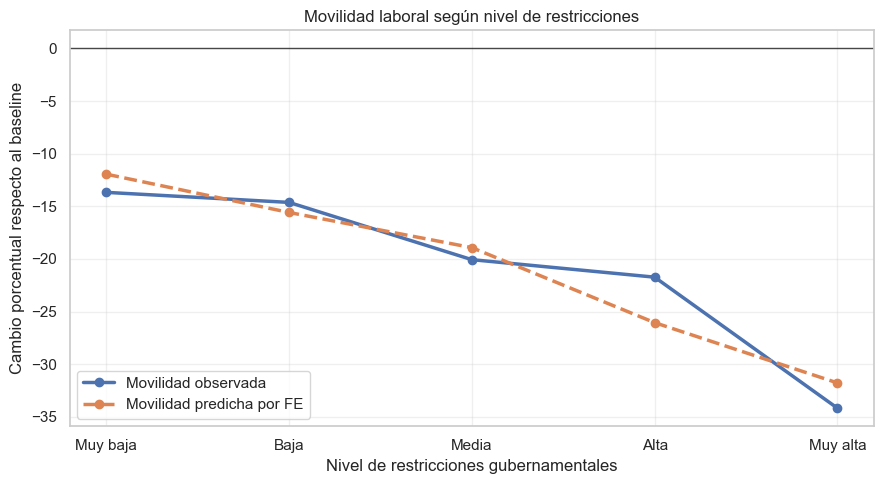

In [20]:
df_plot = df_modelo.copy()

if "NAME" not in df_plot.columns or "date" not in df_plot.columns:
    df_plot = df_plot.reset_index()

df_plot = df_plot.set_index(["NAME", "date"])

pred_fe = fe.predict(fitted=True, effects=True)

df_plot = df_plot.loc[pred_fe.index].copy()
df_plot["pred_FE"] = pred_fe["fitted_values"]

if "estimated_effects" in pred_fe.columns:
    df_plot["pred_FE"] = df_plot["pred_FE"] + pred_fe["estimated_effects"]

df_plot = df_plot.reset_index()

df_plot["nivel_restriccion"] = pd.qcut(
    df_plot["Valor_Stringency_Index"].rank(method="first"),
    q=5,
    labels=["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
)

resumen_restriccion = df_plot.groupby("nivel_restriccion", observed=True).agg(
    movilidad_observada=("workplaces", "mean"),
    movilidad_predicha_FE=("pred_FE", "mean"),
    stringency_promedio=("Valor_Stringency_Index", "mean")
).reset_index()

display(resumen_restriccion.round(2))

plt.figure(figsize=(9, 5))

plt.plot(
    resumen_restriccion["nivel_restriccion"],
    resumen_restriccion["movilidad_observada"],
    marker="o",
    linewidth=2.5,
    label="Movilidad observada"
)

plt.plot(
    resumen_restriccion["nivel_restriccion"],
    resumen_restriccion["movilidad_predicha_FE"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Movilidad predicha por FE"
)

plt.axhline(0, color="black", linewidth=1, alpha=0.7)
plt.title("Movilidad laboral según nivel de restricciones")
plt.xlabel("Nivel de restricciones gubernamentales")
plt.ylabel("Cambio porcentual respecto al baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

R P7: Considerando los modelos anteriores, el modelo que prefiero es el de efectos fijos (FE). La razón principal es que el test de Hausman rechaza el supuesto del modelo de efectos aleatorios, ya que su p-value es menor a 0.05. Esto indica que existen diferencias no observadas entre ciudades que están correlacionadas con las variables explicativas, por lo que RE podría entregar estimaciones inconsistentes. Además, el modelo CRE confirma esta idea, ya que algunas variables promedio por ciudad resultan significativas, mostrando que la heterogeneidad fija entre ciudades sí importa.

En términos generales, la variable más importante para la tesis principal sigue siendo Valor_Stringency_Index, que se sigue manteniendo negativa y significativa en todos los modelos. En Pooled OLS el coeficiente fue -0.4186, en efectos fijos fue -0.4503, en efectos aleatorios fue -0.4475 y en CRE fue -0.4506. Esto indica que un aumento de 10 puntos en el índice de restricciones se asocia con una baja aproximada de 4.2 a 4.5 puntos porcentuales en workplaces. Sin embargo, el resultado no depende solo de esta variable: log_daily_cases también es significativo y positivo en todos los modelos, lo que puede reflejar adaptación social, reaperturas o que los contagios aumentaban en etapas donde la movilidad ya se estaba recuperando. Además, variables como construction, industry, age_dependency y unemp muestran que la movilidad laboral también depende de sectores productivos, caracteristicas demográficas y del mercado laboral de cada ciudad.

Por lo tanto, usando efectos fijos como modelo principal de referencia, se puede inferir que las restricciones gubernamentales tuvieron un efecto negativo y estadísticamente significativo sobre la movilidad laboral, incluso controlando por casos COVID, tamaño poblacional, sectores productivos, dependencia etaria, desempleo y año. La lectura más completa es que la movilidad laboral durante la pandemia no solo fue por las restricciones formales, sino también puede estar relacionado a la composición económica y social de cada ciudad. Aun así, la señal más robusta del análisis es que mayores restricciones se relacionan sistemáticamente con menor movilidad laboral.

8. Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados (instalar libreria pysyncon)


In [21]:
from pysyncon import Dataprep, Synth, AugSynth
import matplotlib.pyplot as plt

datos_sc = df_modelo.copy()

if "NAME" not in datos_sc.columns or "date" not in datos_sc.columns:
    datos_sc = datos_sc.reset_index()

datos_sc["date"] = pd.to_datetime(datos_sc["date"])
datos_sc["log_population"] = np.log(datos_sc["Population"])
datos_sc["log_daily_cases"] = np.log1p(datos_sc["daily_cases"])

ciudad_tratada = "Nice"
pais_tratado = "FR"
semana_tratamiento = 36

fecha_tratamiento = datos_sc.loc[
    (datos_sc["NAME"] == ciudad_tratada) &
    (datos_sc["week"] == semana_tratamiento),
    "date"
].iloc[0]

print(f"Ciudad tratada: {ciudad_tratada}")
print(f"País tratado: {pais_tratado}")
print(f"Semana de tratamiento: {semana_tratamiento}")
print(f"Fecha de tratamiento: {fecha_tratamiento.date()}")

Ciudad tratada: Nice
País tratado: FR
Semana de tratamiento: 36
Fecha de tratamiento: 2020-10-19


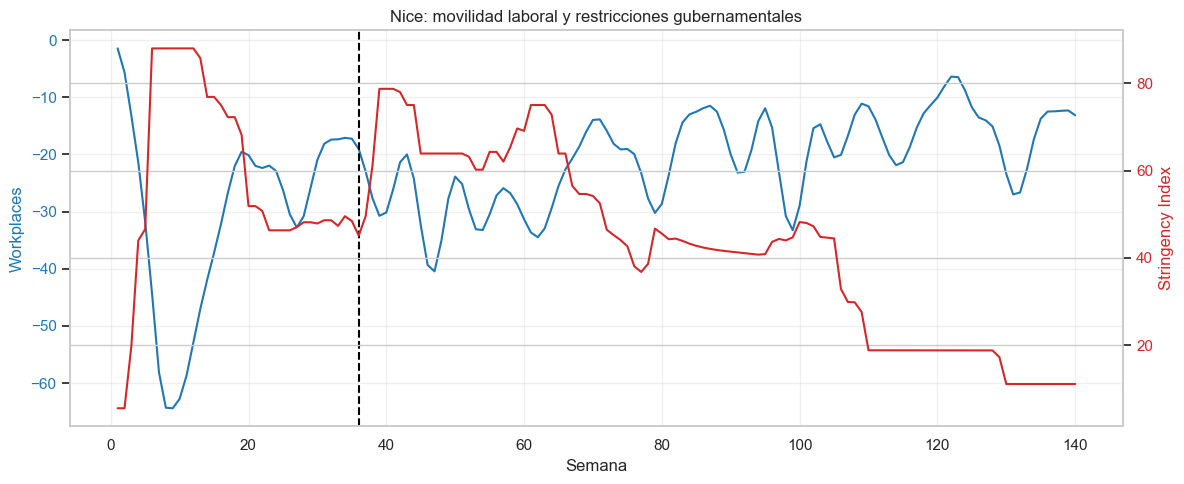

In [22]:
ciudad_data = datos_sc[datos_sc["NAME"] == ciudad_tratada].copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(ciudad_data["week"],
  ciudad_data["workplaces"],
  color="tab:blue",
  label="Movilidad laboral"
  )
ax1.set_ylabel("Workplaces", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(
ciudad_data["week"],
ciudad_data["Valor_Stringency_Index"],
color="tab:red",
label="Stringency Index"
)
ax2.set_ylabel("Stringency Index", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.axvline(x=semana_tratamiento, color="black", linestyle="--", linewidth=1.5)

ax1.set_title("Nice: movilidad laboral y restricciones gubernamentales")
ax1.set_xlabel("Semana")
ax1.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [23]:
controles = sorted(
    datos_sc.loc[
        (datos_sc["country"] != "DE") &
        (datos_sc["NAME"] != ciudad_tratada),
        "NAME"
    ].unique()
)

print(f"Número de ciudades control: {len(controles)}")
print(controles)

Número de ciudades control: 46
['A Coruña', 'Alicante/Alacant', 'Angers', 'Barcelona', 'Bari', 'Bilbao', 'Bologna', 'Bordeaux', 'Catania', 'Córdoba', 'Dijon', 'Elche/Elx', 'Firenze', 'Genova', 'Granada', 'Jerez de la Frontera', 'Las Palmas', 'Lens', 'Lille', 'Malmö', 'Marseille', 'Messina', 'Milano', 'Montpellier', 'Mulhouse', 'Málaga', 'Nantes', 'Napoli', 'Padova', 'Palermo', 'Palma de Mallorca', 'Paris', 'Roma', 'Rouen', 'Sevilla', 'Stockholm', 'Strasbourg', 'Torino', 'Toulon', 'Tours', 'Valencia', 'Venezia', 'Verona', 'Vigo', 'Vitoria/Gasteiz', 'Zaragoza']


In [24]:
dataprep_nice = Dataprep(
  foo=datos_sc,
  predictors=[
      "log_population",
      "agriculture",
      "industry",
      "construction",
      "age_dependency",
      "unemp",
      "Valor_Stringency_Index",
      "log_daily_cases"
  ],
  predictors_op="mean",
  time_predictors_prior=range(1, semana_tratamiento),
  special_predictors=[
      ("workplaces", range(1, 13), "mean"),
      ("workplaces", range(13, 26), "mean"),
      ("workplaces", range(26, semana_tratamiento), "mean"),
  ],
  dependent="workplaces",
  unit_variable="NAME",
  time_variable="week",
  treatment_identifier=ciudad_tratada,
  controls_identifier=controles,
  time_optimize_ssr=range(1, semana_tratamiento),
)

In [25]:
synth_nice = Synth()
synth_nice.fit(
    dataprep=dataprep_nice,
    optim_method="Nelder-Mead",
  optim_initial="ols"
  )
print("Pesos del control sintético clásico:")
display(synth_nice.weights().sort_values(ascending=False).head(10))

Pesos del control sintético clásico:


Toulon             0.477
Marseille          0.294
Paris              0.209
A Coruña           0.015
Stockholm          0.005
Alicante/Alacant   0.000
Bologna            0.000
Bordeaux           0.000
Catania            0.000
Córdoba            0.000
Name: weights, dtype: float64

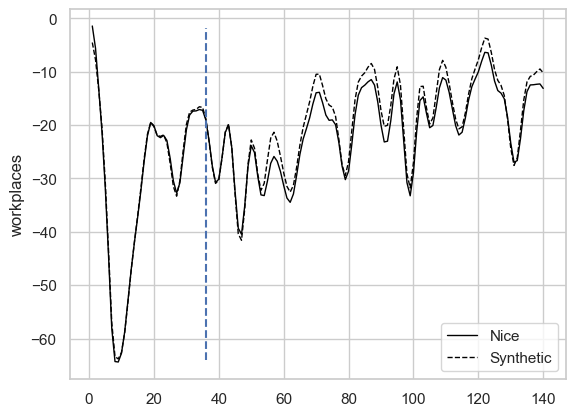

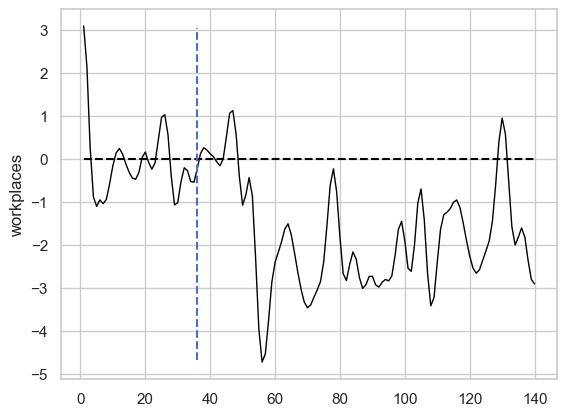

,V,treated,synthetic,sample mean
log_population,0.001,6.137,6.687,6.239
agriculture,0.001,0.005,0.006,0.011
industry,0.014,0.064,0.084,0.112
construction,0.000,0.077,0.057,0.065
age_dependency,0.005,0.837,0.775,0.682
unemp,0.000,20.000,16.766,17.519
Valor_Stringency_Index,0.077,58.219,58.223,62.123
log_daily_cases,0.135,4.585,4.581,4.664
special.1.workplaces,0.424,-39.923,-39.944,-38.866
special.2.workplaces,0.302,-27.863,-27.837,-27.526


In [26]:
synth_nice.path_plot(
    time_period=range(1, 141),
  treatment_time=semana_tratamiento
  )

synth_nice.gaps_plot(
    time_period=range(1, 141),
    treatment_time=semana_tratamiento
    )
synth_nice.summary()

AUGSYNTH

In [27]:
augsynth_nice = AugSynth()
augsynth_nice.fit(dataprep=dataprep_nice)
print("Pesos del Augmented Synthetic Control:")
display(augsynth_nice.weights().sort_values(ascending=False).head(10))

Pesos del Augmented Synthetic Control:


Toulon      0.471
Granada     0.410
Lens        0.293
Marseille   0.273
Paris       0.244
Mulhouse    0.242
Zaragoza    0.180
Bologna     0.138
Tours       0.113
Venezia     0.111
Name: weights, dtype: float64

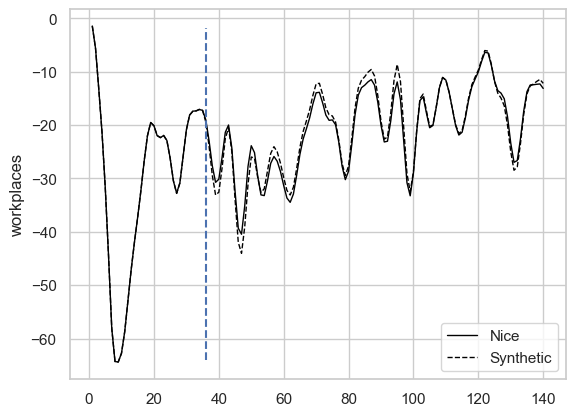

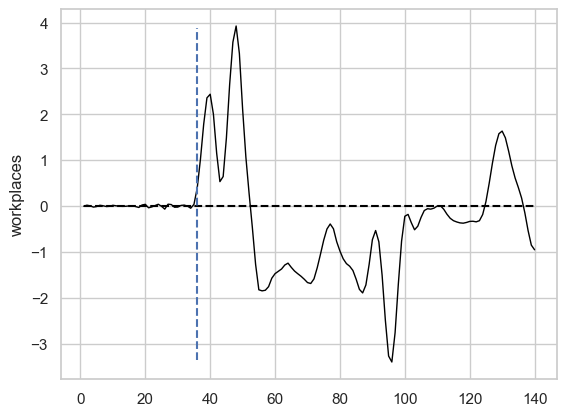

,treated,synthetic,sample mean
log_population,6.137,6.138,6.239
agriculture,0.005,0.005,0.011
industry,0.064,0.064,0.112
construction,0.077,0.077,0.065
age_dependency,0.837,0.837,0.682
unemp,20.000,20.000,17.519
Valor_Stringency_Index,58.219,58.225,62.123
log_daily_cases,4.585,4.584,4.664
special.1.workplaces,-39.923,-39.924,-38.866
special.2.workplaces,-27.863,-27.863,-27.526


In [28]:
augsynth_nice.path_plot(
  time_period=range(1, 141),
  treatment_time=semana_tratamiento)

augsynth_nice.gaps_plot(
    time_period=range(1, 141),
    treatment_time=semana_tratamiento)

augsynth_nice.summary()

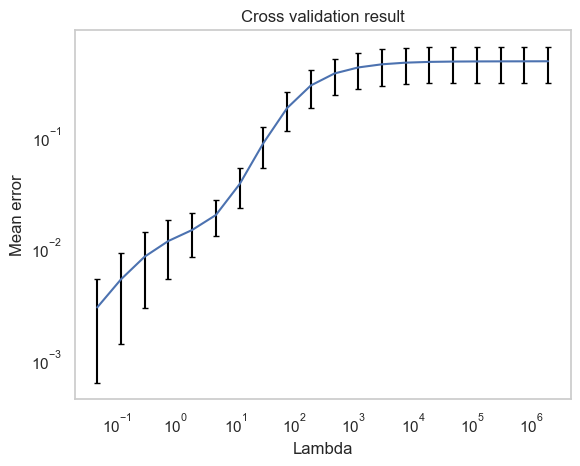

In [29]:
augsynth_nice.cv_result.plot()
plt.show()

In [30]:
pre_periodo = range(1, semana_tratamiento)
post_periodo = range(semana_tratamiento, 141)

att_pre_synth = synth_nice.att(time_period=pre_periodo)
att_post_synth = synth_nice.att(time_period=post_periodo)

att_pre_aug = augsynth_nice.att(time_period=pre_periodo)
att_post_aug = augsynth_nice.att(time_period=post_periodo)

print("Control sintético clásico")
print(f"Gap promedio pre-tratamiento: {att_pre_synth['att']:.3f}")
print(f"Gap promedio post-tratamiento: {att_post_synth['att']:.3f}")
print(f"Error estándar post: {att_post_synth['se']:.3f}")

print("\nAugmented Synthetic Control")
print(f"Gap promedio pre-tratamiento: {att_pre_aug['att']:.3f}")
print(f"Gap promedio post-tratamiento: {att_post_aug['att']:.3f}")
print(f"Error estándar post: {att_post_aug['se']:.3f}")

Control sintético clásico
Gap promedio pre-tratamiento: -0.087
Gap promedio post-tratamiento: -1.779
Error estándar post: 0.123

Augmented Synthetic Control
Gap promedio pre-tratamiento: 0.000
Gap promedio post-tratamiento: -0.327
Error estándar post: 0.134


R P8: Para aplicar control sintético se eligió la ciudad de Niza, en Francia. La semana de tratamiento definida fue la semana 36, correspondiente al 19 de octubre de 2020, ya que desde ese periodo se observa un aumento bastante importante en el índice de restricciones gubernamentales y un cambio en la movilidad laboral. La idea de este enunciado es construir una ciudad “Niza sintética” que replique lo mejor posible el comportamiento previo de Niza, para luego comparar qué ocurre después del tratamiento.

Siguiendo la lógica del notebook de referencia, se usaron como controles potenciales todas las ciudades disponibles del dataset, excluyendo Alemania por los problemas detectados en sus dstintas variables y excluyendo Niza. Para construir el control sintético se utilizaron estas variables: log_population, agriculture, industry, construction, age_dependency, unemp, Valor_Stringency_Index y log_daily_cases. Además, se agregaron predictores especiales con promedios de workplaces en distintos tramos del periodo pre-tratamiento, para asegurar que el sintético replicara bien la evolución previa de la movilidad laboral.

En el control sintético clásico, los mayores pesos fueron asignados a Tolón, Marsella y Paris. Esto es positivo, ya que son ciudades francesas y por lo tanto más comparables institucionalmente con Niza. Además, el balance previo al tratamiento fue bastante bueno: el índice de restricciones de Niza fue 58.219 y el del sintético 58.223; log_daily_cases fue 4.585 para Niza y 4.581 para el sintético; y los promedios previos de workplaces también quedaron muy cercanos. Esto indica que el escenario ficticio construido es razonable para analizar la evolución posterior.

Luego se estimó también Augmented Synthetic Control. Este método logra un ajuste aún más exacto en las variables previas, pero debe interpretarse con más cautela porque incorpora una corrección adicional y puede extrapolar más que el control sintético clásico. Por eso, lo tomo como un ejercicio de robustez más que como el resultado principal.

Al calcular el gap promedio, el control sintético clásico muestra un gap pre-tratamiento de -0.087, muy cercano a cero, lo que confirma que la Niza sintética replica bien a Niza antes de la semana 36. En el periodo despues, el gap promedio fue de -1.779, indicando que Niza tuvo en promedio cerca de 1.8 puntos porcentuales menos de movilidad laboral que su ficticia. Con Augmented Synthetic Control, el gap pre-tratamiento fue 0.000 y el gap post-tratamiento fue -0.327, por lo que la dirección del efecto se mantiene negativa, aunque con menor magnitud. En conjunto, estos resultados sugieren que el aumento de restricciones estuvo asociado a una reducción de la movilidad laboral en Niza, aunque el tamaño exacto del efecto depende del método que se use.

En conclusión, el ejercicio de control sintético permite complementar los modelos de panel anteriores. Mientras los modelos Pooled, efectos fijos, efectos aleatorios y CRE mostraban una relación negativa y significativa entre restricciones gubernamentales y movilidad laboral, el control sintético permite observar esta relación para una ciudad específica comparándola con su ficticia. En el caso de Niza, el buen ajuste pre-tratamiento permite interpretar las diferencias posteriores como evidencia compatible con un efecto de las restricciones sobre la movilidad laboral, aunque con la precaución de que las ciudades control también pudieron estar expuestas a dinámicas nacionales similares durante la pandemia.